In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import os
import umap
import pathlib

/home/shade/miniconda3/envs/rapids/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1779488516.629284    5487 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779488516.941555    5487 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779488519.196030    5487 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floati

In [2]:
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

pathlib.Path('plots').mkdir(exist_ok=True)
pathlib.Path('results').mkdir(exist_ok=True)

In [3]:
core_path = os.getcwd()   # adjust if needed
orbital_df = pd.read_pickle(os.path.join(core_path, "data/lvl3/", "orbital_df.pkl"))

# Slice to family members only
family_df = orbital_df[orbital_df['is_family_member']].copy().reset_index(drop=True)

print(f"Working dataset : {len(family_df):,} family members")
print(f"Unique families : {family_df['family_1'].nunique()}")

Working dataset : 230,607 family members
Unique families : 98


In [4]:
FEATURES = ['a_p', 'e_p', 'sin_i_p', 'g', 's']

X_raw = family_df[FEATURES].values
scaler = RobustScaler()
X = scaler.fit_transform(X_raw)

print(f"Feature matrix shape : {X.shape}")
print(f"Features used        : {FEATURES}")

Feature matrix shape : (230607, 5)
Features used        : ['a_p', 'e_p', 'sin_i_p', 'g', 's']


In [5]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,      # local structure — good for tight family clusters
    min_dist=0.05,       # compressed clusters
    metric='euclidean',
    random_state=42,
    verbose=True
)

embedding = reducer.fit_transform(X)
family_df['umap_x'] = embedding[:, 0]
family_df['umap_y'] = embedding[:, 1]

print(f"Embedding shape: {embedding.shape}")

/home/shade/miniconda3/envs/rapids/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.05, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sat May 23 03:52:43 2026 Construct fuzzy simplicial set
Sat May 23 03:52:44 2026 Finding Nearest Neighbors
Sat May 23 03:52:44 2026 Building RP forest with 29 trees
Sat May 23 03:52:47 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	Stopping threshold met -- exiting after 2 iterations
Sat May 23 03:53:24 2026 Finished Nearest Neighbor Search
Sat May 23 03:53:30 2026 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  10%| █          21/200 [00:13]

...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [02:03]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [02:15]

Sat May 23 03:56:32 2026 Finished embedding
Embedding shape: (230607, 2)


/tmp/ipykernel_5487/1279690021.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap('turbo', len(unique_fams))


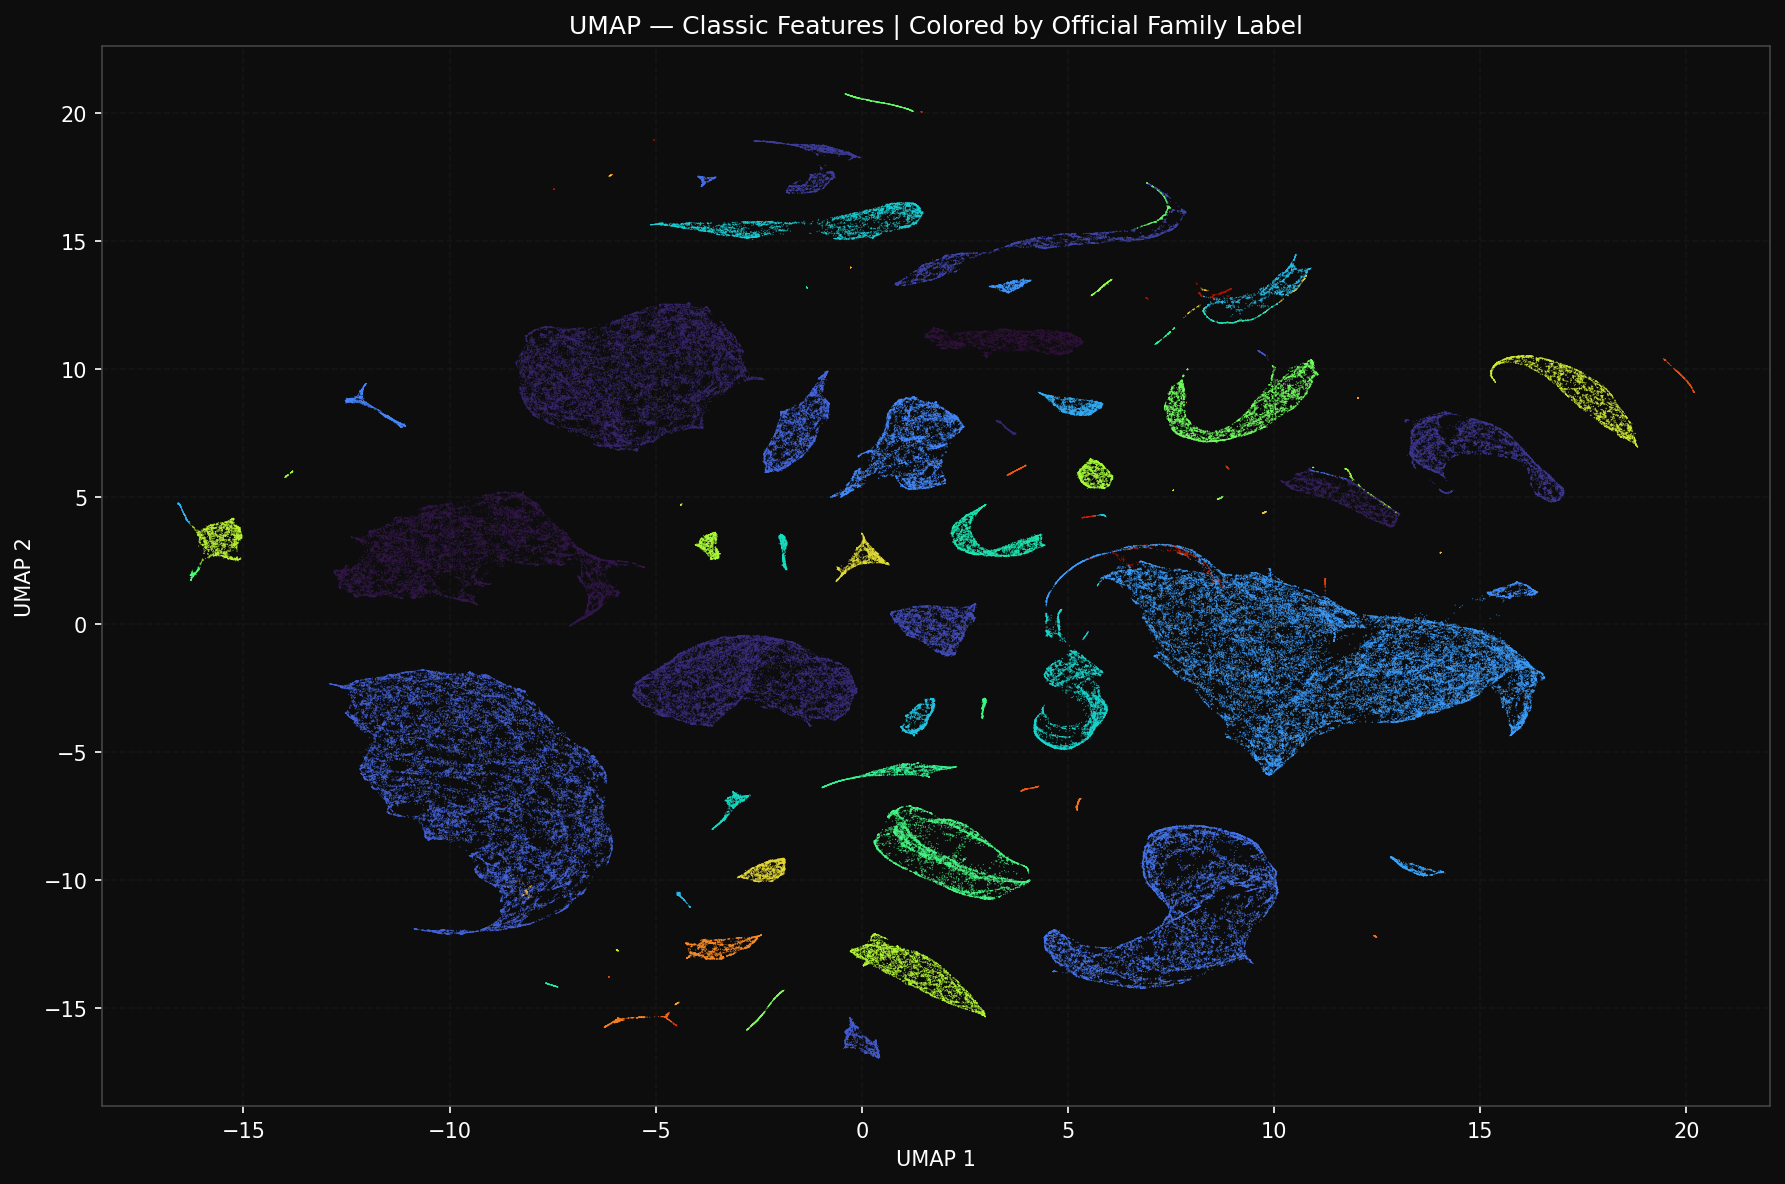

In [21]:
# Build color map for 98 families
unique_fams = family_df['family_1'].unique()
cmap        = plt.cm.get_cmap('turbo', len(unique_fams))
fam_to_color = {f: cmap(i) for i, f in enumerate(unique_fams)}
colors       = family_df['family_1'].map(fam_to_color)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(embedding[:, 0], embedding[:, 1],
           c=colors, s=0.3, alpha=0.7, linewidths=0)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP — Classic Features | Colored by Official Family Label')
ax.grid(True)

plt.tight_layout()
plt.savefig('plots/05c_umap__extended_official.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
C1, C2, C3 = 5/4, 2, 2

a     = family_df['a_p'].values
e     = family_df['e_p'].values
si    = family_df['sin_i_p'].values
n     = family_df['n'].values
g     = family_df['g'].values
s     = family_df['s'].values
n_rad = np.deg2rad(n)

# For the KDTree we need a unified weighted feature matrix
# Geometric elements get Zappalà weights, g and s get IQR-normalized weights
X_hcm = np.column_stack([a, e, si, n_rad, g, s])

print(f"X_hcm shape: {X_hcm.shape}")
print("Ready for KDTree clustering")

X_hcm shape: (230607, 6)
Ready for KDTree clustering


In [8]:
from sklearn.neighbors import KDTree

D_CUT = 60   # m/s

zones = {
    'inner' : (2.0,  2.5),
    'middle': (2.5,  2.95),
    'outer' : (2.95, 3.5),
}

hcm_labels      = np.full(len(family_df), -1, dtype=int)
cluster_counter = 0

for zone_name, (a_min, a_max) in zones.items():
    mask   = (family_df['a_p'] >= a_min) & (family_df['a_p'] < a_max)
    idx    = np.where(mask)[0]
    X_zone = X_hcm[idx]

    print(f"\nZone {zone_name}: {len(idx):,} objects")

    a_mean   = X_zone[:, 0].mean()
    n_mean   = X_zone[:, 3].mean()
    scale    = n_mean * a_mean * 1731.46
    r_search = D_CUT / scale

    # Zappalà weights for geometric elements
    w_a  = np.sqrt(C1)
    w_e  = np.sqrt(C2)
    w_si = np.sqrt(C3)

    # IQR-based weights for g and s — normalize to same scale as a_p contribution
    a_iqr = np.subtract(*np.percentile(X_zone[:, 0], [75, 25]))
    g_iqr = np.subtract(*np.percentile(X_zone[:, 4], [75, 25]))
    s_iqr = np.subtract(*np.percentile(X_zone[:, 5], [75, 25]))

    DAMP = 0.15   # tune this: 0.1–0.3

    w_g = (a_iqr / g_iqr) * w_a * DAMP if g_iqr > 0 else 0
    w_s = (a_iqr / s_iqr) * w_a * DAMP if s_iqr > 0 else 0

    # Apply weights to ALL 5 features (drop n_rad column — only used for scale)
    X_geo = np.column_stack([
        X_zone[:, 0] * w_a,    # a_p
        X_zone[:, 1] * w_e,    # e_p
        X_zone[:, 2] * w_si,   # sin_i_p
        X_zone[:, 4] * w_g,    # g
        X_zone[:, 5] * w_s,    # s
    ])

    # KDTree on ALL 5 weighted features — this is the key fix
    tree   = KDTree(X_geo)
    parent = np.arange(len(idx))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        px, py = find(x), find(y)
        if px != py:
            parent[px] = py

    print(f"  Running neighbor search & union-find...")
    for i in range(len(idx)):
        neighbors = tree.query_radius([X_geo[i]], r=r_search)[0]
        for j in neighbors:
            if j != i:
                union(i, j)

    root_to_label = {}
    zone_labels   = np.zeros(len(idx), dtype=int)
    for i in range(len(idx)):
        root = find(i)
        if root not in root_to_label:
            root_to_label[root] = cluster_counter
            cluster_counter    += 1
        zone_labels[i] = root_to_label[root]

    hcm_labels[idx] = zone_labels
    print(f"  Clusters found: {len(np.unique(zone_labels)):,}")

family_df['hcm_label'] = hcm_labels
print(f"\nTotal HCM clusters : {family_df['hcm_label'].nunique():,}")


Zone inner: 63,107 objects
  Running neighbor search & union-find...
  Clusters found: 16

Zone middle: 97,467 objects
  Running neighbor search & union-find...
  Clusters found: 102

Zone outer: 70,033 objects
  Running neighbor search & union-find...
  Clusters found: 42

Total HCM clusters : 160


In [13]:
ARI = adjusted_rand_score(family_df['family_1'], family_df['hcm_label'])
NMI = normalized_mutual_info_score(family_df['family_1'], family_df['hcm_label'])

print(f"=== HCM Evaluation (Extended Features, d_cut={D_CUT} m/s) ===")
print(f"Adjusted Rand Index (ARI) : {ARI:.4f}")
print(f"Normalized Mutual Info    : {NMI:.4f}")
print(f"Official families         : {family_df['family_1'].nunique()}")
print(f"HCM clusters found        : {family_df['hcm_label'].nunique()}")

# Compare to classic
print(f"\n=== Comparison ===")
print(f"{'':>30} {'Classic':>10} {'Extended':>10}")
print(f"{'ARI':>30} {'0.7945':>10} {ARI:>10.4f}")
print(f"{'NMI':>30} {'0.9446':>10} {NMI:>10.4f}")
print(f"{'Clusters found':>30} {'132':>10} {family_df['hcm_label'].nunique():>10}")

=== HCM Evaluation (Extended Features, d_cut=60 m/s) ===
Adjusted Rand Index (ARI) : 0.7945
Normalized Mutual Info    : 0.9445
Official families         : 98
HCM clusters found        : 160

=== Comparison ===
                                  Classic   Extended
                           ARI     0.7945     0.7945
                           NMI     0.9446     0.9445
                Clusters found        132        160


In [14]:
cluster_sizes = pd.Series(hcm_labels).value_counts()

print(cluster_sizes.describe())
print("\nSingleton clusters:", (cluster_sizes == 1).sum())
print("Clusters < 5 members:", (cluster_sizes < 5).sum())

count      160.000000
mean      1441.293750
std       5238.063299
min          1.000000
25%          1.000000
50%          4.500000
75%        467.250000
max      42753.000000
Name: count, dtype: float64

Singleton clusters: 54
Clusters < 5 members: 80


/tmp/ipykernel_5487/3669850201.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_hcm      = plt.cm.get_cmap('turbo', len(unique_hcm))


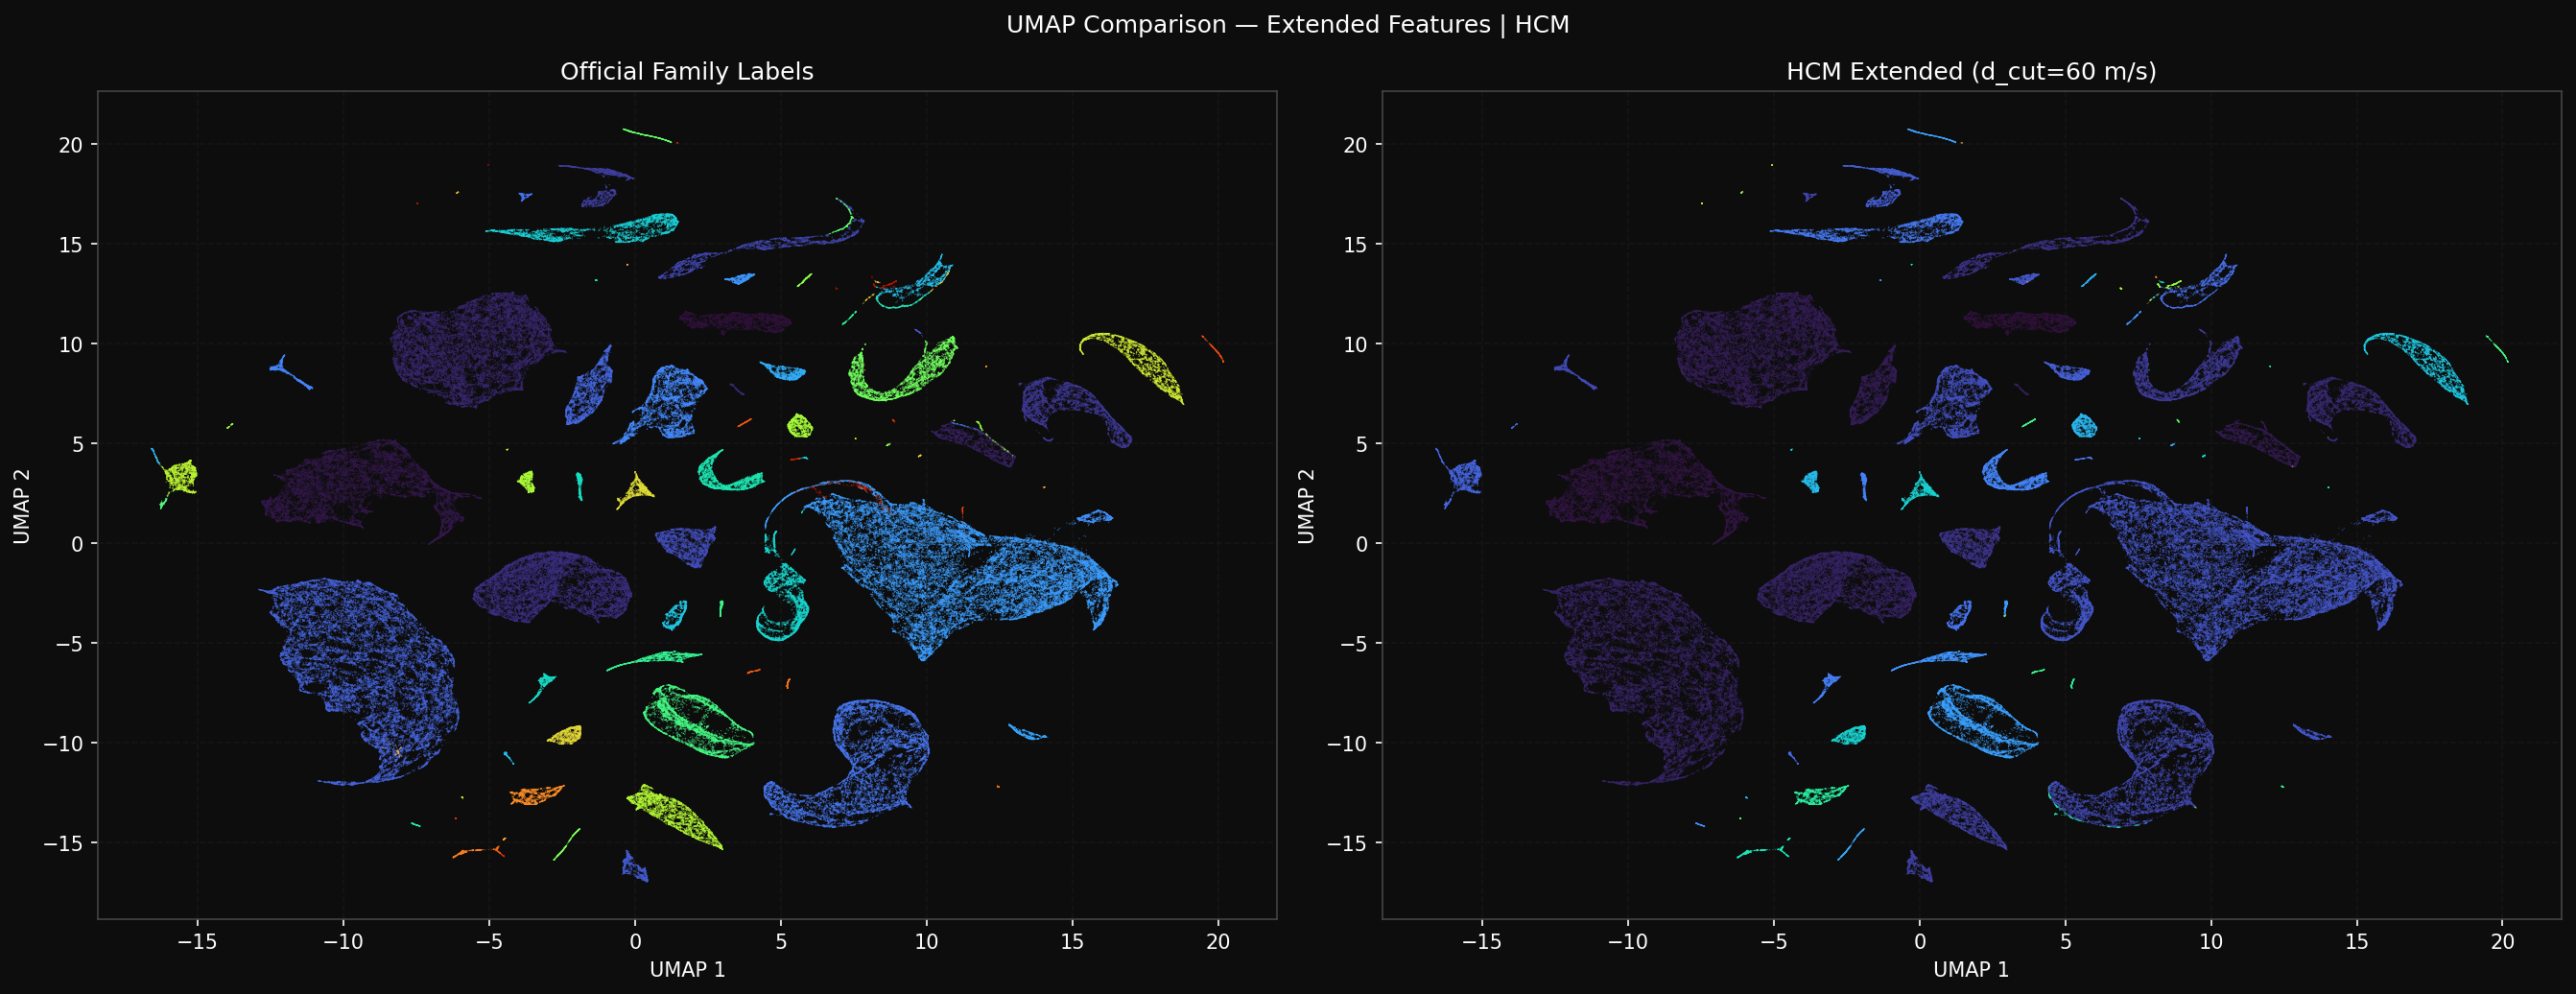

In [22]:
unique_hcm    = family_df['hcm_label'].unique()
cmap_hcm      = plt.cm.get_cmap('turbo', len(unique_hcm))
hcm_to_color  = {h: cmap_hcm(i) for i, h in enumerate(unique_hcm)}
colors_hcm    = family_df['hcm_label'].map(hcm_to_color)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, c, title in zip(
    axes,
    [colors, colors_hcm],
    ['Official Family Labels', f'HCM Extended (d_cut={D_CUT} m/s)'],
):
    ax.scatter(embedding[:, 0], embedding[:, 1],
               c=c, s=0.3, alpha=0.7, linewidths=0)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(title)
    ax.grid(True)

plt.suptitle('UMAP Comparison — Extended Features | HCM', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join('plots/05c_umap__extended_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

In [16]:
pathlib.Path(os.path.join(core_path, "data/results")).mkdir(parents=True, exist_ok=True)

family_df[['Asteroid_id', 'family_1', 'hcm_label', 'umap_x', 'umap_y']].to_pickle(
    os.path.join(core_path, 'data/results/05c_hcm_extended_results.pkl')
)